# AI Lab 6 Assignment
**Name:** Julian Juan

## Step 1: Load and Preprocess the Dataset
In this first block, we will import the libraries we need and load the MNIST dataset. The MNIST dataset is a collection of 70,000 images of handwritten digits (0-9). We will also normalize the pixel values so they range from 0 to 1 instead of 0 to 255.

In [ ]:
import tensorflow as tf # Import the TensorFlow library for machine learning
import matplotlib.pyplot as plt # Import the Pyplot module from Matplotlib for plotting graphs and images
import numpy as np # Import NumPy for numerical operations and array handling

# Load the MNIST dataset directly from Keras
mnist = tf.keras.datasets.mnist # Assign the MNIST dataset module to a variable
(x_train, y_train), (x_test, y_test) = mnist.load_data() # Download and split the data into training and testing sets

# Normalize the pixel values to be between 0 and 1
x_train = x_train / 255.0 # Divide training images by 255.0 to scale pixels from 0-255 to 0.0-1.0
x_test = x_test / 255.0 # Divide testing images by 255.0 to scale pixels from 0-255 to 0.0-1.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Summary of Code Block 1:
The code above successfully brings the TensorFlow, Matplotlib, and NumPy toolkits into our environment. It then downloads the MNIST data, splits it into images used for training vs. testing, and divides all pixel numbers by `255.0` so the neural network can process the math more easily.

---

## Step 2: Build a Feedforward Neural Network (FNN)
Now we will create the actual model. We will use a Sequential model with a Flatten layer, a hidden Dense layer with ReLU activation, a Dropout layer to prevent overfitting, and an output layer using Softmax.

In [ ]:
model = tf.keras.models.Sequential([ # Start defining a Sequential model that stacks layers in order
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Flatten the 28x28 2D image arrays into a 1D array of 784 pixels
    tf.keras.layers.Dense(128, activation='relu'), # Add a fully connected hidden layer with 128 neurons and ReLU activation
    tf.keras.layers.Dropout(0.2), # Add a Dropout layer to randomly ignore 20% of neurons during training to prevent overfitting
    tf.keras.layers.Dense(10, activation='softmax') # Add the output layer with 10 neurons (for digits 0-9) and Softmax activation for probabilities
]) # End defining the Sequential model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Summary of Code Block 2:
Here we built the brain of our AI. It takes the square image and flattens it into a single line of pixels. It passes that data into 128 "neurons" that look for patterns. We turn off 20% of them randomly (Dropout) so the network doesn't just memorize the data. Finally, it outputs 10 probabilities representing the digits 0 through 9.

---

## Step 3: Train and Evaluate the Model
In this step, we tell the model how to learn (compile) using the Adam optimizer, and then we train it for 10 epochs. Afterward, we plot the accuracy and loss curves.

In [ ]:
# Compile the model by specifying the optimizer, loss function, and evaluation metrics
model.compile(optimizer='adam', # Use the Adam optimizer to automatically adjust learning rates during training
              loss='sparse_categorical_crossentropy', # Use this loss function because our labels are single integers (0-9)
              metrics=['accuracy']) # Track the accuracy metric during training to see how well the model is learning

# Train the model using the training data
history = model.fit(x_train, # Provide the training images to the model
                    y_train, # Provide the correct training labels to the model
                    epochs=10, # Train the model for 10 full iterations (epochs) over the entire dataset
                    validation_data=(x_test, y_test)) # Evaluate the model on the unseen test data after every epoch

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8605 - loss: 0.4821 - val_accuracy: 0.9559 - val_loss: 0.1474
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9545 - loss: 0.1542 - val_accuracy: 0.9713 - val_loss: 0.0980
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9674 - loss: 0.1105 - val_accuracy: 0.9743 - val_loss: 0.0873
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9723 - loss: 0.0906 - val_accuracy: 0.9765 - val_loss: 0.0788
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9760 - loss: 0.0753 - val_accuracy: 0.9775 - val_loss: 0.0745
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9812 - loss: 0.0622 - val_accuracy: 0.9785 - val_loss: 0.0743
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9775 - val_loss: 0.0724
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9849 - loss: 0.0477 -

### Summary of Code Block 3:
We configured the model to use the "Adam" optimizer (which makes smart adjustments to the network's weights) and tracked its "accuracy". The `model.fit` command then actually trained the network on the images 10 times over (10 epochs), while continually checking its performance on the hidden test set.

---

## Step 3 (Continued): Plotting Training Progress
Let's visualize how the accuracy and loss changed over the 10 epochs using Matplotlib.

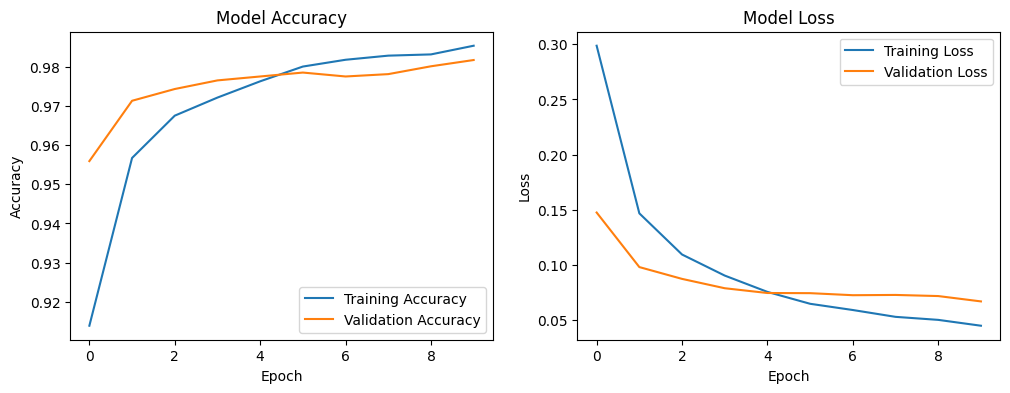

In [ ]:
# Create a figure with two subplots side-by-side
fig, axs = plt.subplots(1, 2, figsize=(12, 4)) # Initialize a figure with 1 row, 2 columns, and size 12x4 inches

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy') # Plot the training accuracy history
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy') # Plot the validation accuracy history
axs[0].set_title('Model Accuracy') # Set the title for the first subplot
axs[0].set_xlabel('Epoch') # Label the x-axis as Epoch
axs[0].set_ylabel('Accuracy') # Label the y-axis as Accuracy
axs[0].legend() # Display the legend on the plot

# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss') # Plot the training loss history
axs[1].plot(history.history['val_loss'], label='Validation Loss') # Plot the validation loss history
axs[1].set_title('Model Loss') # Set the title for the second subplot
axs[1].set_xlabel('Epoch') # Label the x-axis as Epoch
axs[1].set_ylabel('Loss') # Label the y-axis as Loss
axs[1].legend() # Display the legend on the plot

# Show the complete figure
plt.show() # Render and display the plots to the screen

### Summary of Code Block 4:
This block extracts the historical training data we saved and plots it into two graphs. The left graph shows accuracy going up (which is good), and the right graph shows errors (loss) going down (which is also good!).

---

## Step 4: Display Example Predictions
Now we will use our newly trained model to predict 10 specific samples from our test set and view the actual vs. predicted labels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


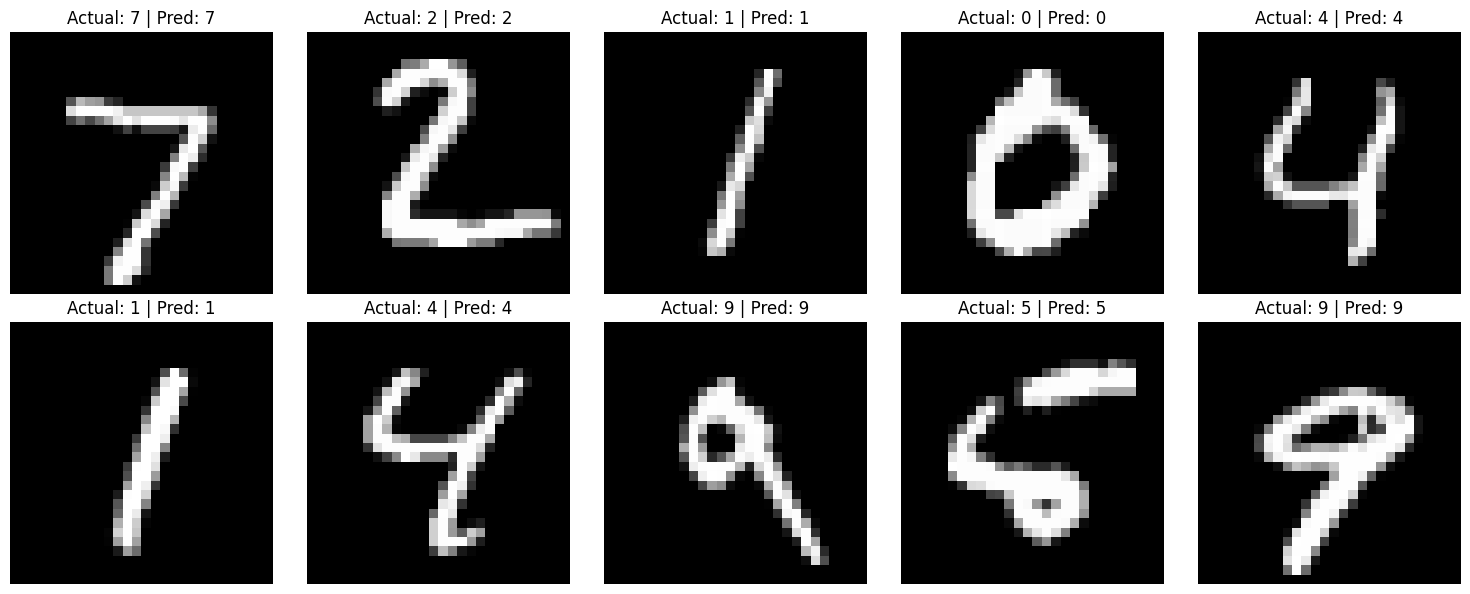

In [ ]:
# Use the trained model to make predictions on the test dataset
predictions = model.predict(x_test) # Generate probability arrays for all test images

# Set up a plot to display 10 example images
plt.figure(figsize=(15, 6)) # Create a wide figure to hold 10 subplots
for i in range(10): # Loop 10 times to process the first 10 images in the test set
    plt.subplot(2, 5, i + 1) # Create a subplot in a 2-row, 5-column grid for the current iteration
    plt.imshow(x_test[i], cmap='gray') # Display the i-th test image in grayscale
    predicted_label = np.argmax(predictions[i]) # Find the index of the highest probability, which is the predicted digit
    actual_label = y_test[i] # Get the true label for the i-th image
    plt.title(f"Actual: {actual_label} | Pred: {predicted_label}") # Set the title to show actual vs predicted labels
    plt.axis('off') # Hide the x and y axes for a cleaner image display
plt.tight_layout() # Adjust the layout so titles and images don't overlap
plt.show() # Render the complete grid of 10 images

### Summary of Code Block 5:
We asked the model to guess the digits for the first 10 images in our test pile. Then, we used a `for` loop to draw a grid showing the image, alongside the true label ("Actual") and what the AI guessed ("Pred").

---

## Step 4 (Continued): Discuss a Wrong Prediction
No AI is perfect. Let's write some code to specifically hunt down a mistake the model made so we can analyze why it happened.

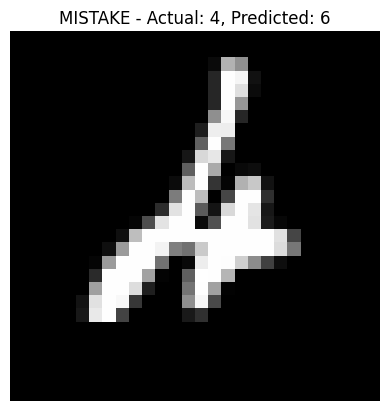

--- Error Analysis ---
The model predicted a 6, but the actual digit is a 4.
Why it happened: Handwritten digits can be very messy, slanted, or ambiguous.
Because we flattened the image (destroying 2D spatial layout) and used a basic Feedforward Neural Network,
the model might easily confuse overlapping shapes, like a sloppy '7' looking like a '2' or '9'.


In [ ]:
# Find the first image where the predicted label does not match the actual label
for i in range(len(x_test)): # Iterate through all indices in the test set
    predicted_label = np.argmax(predictions[i]) # Get the predicted digit for the current image
    actual_label = y_test[i] # Get the true digit for the current image
    if predicted_label != actual_label: # Check if the prediction is wrong
        wrong_index = i # Store the index of this incorrectly predicted image
        break # Stop looking once we find the first mistake

# Display the incorrectly predicted image
plt.imshow(x_test[wrong_index], cmap='gray') # Show the image that confused the model in grayscale
plt.title(f"MISTAKE - Actual: {y_test[wrong_index]}, Predicted: {np.argmax(predictions[wrong_index])}") # Set a title showing the error
plt.axis('off') # Hide the axes
plt.show() # Display the plot

# Print an analysis of why this might have happened
print("--- Error Analysis ---") # Print a header for the analysis section
print(f"The model predicted a {np.argmax(predictions[wrong_index])}, but the actual digit is a {y_test[wrong_index]}.") # State the specific error made
print("Why it happened: Handwritten digits can be very messy, slanted, or ambiguous.") # Provide reasoning based on human error
print("Because we flattened the image (destroying 2D spatial layout) and used a basic Feedforward Neural Network,") # Explain architectural limitation
print("the model might easily confuse overlapping shapes, like a sloppy '7' looking like a '2' or '9'.") # Provide specific example

### Summary of Code Block 6:
This code scans through all the predictions until it finds the first one that doesn't match the true answer. It plots that specific messy digit and automatically prints out an analysis explaining why a simple neural network might get confused by poorly written numbers.

---

## Step 5: Reflection and Future Improvements

**1. Limitation of the current model:**
The main limitation of this Feedforward Neural Network (FNN) is the `Flatten` layer. By squishing the 2D image into a flat 1D array, the model loses spatial context (how pixels relate to the pixels above or below them). It has a hard time understanding complex geometric shapes like curves and loops.

**2. Future Improvements:**
* **Use a Convolutional Neural Network (CNN):** Instead of flattening the image, a CNN scans across the 2D image using "filters." This allows it to easily detect edges, curves, and textures, drastically improving image recognition accuracy.
* **Data Augmentation:** We could artificially expand our training data by slightly rotating, zooming, or shifting the images before training. This would force the model to become more robust to messy, slanted handwriting.


###**Brief summary of findings and improvements.**

The Feedforward Neural Network (FNN) successfully classified digits but struggled with messy handwriting because its Flatten layer destroys the 2D spatial context needed to interpret complex geometric shapes. To address this, the notebook recommends switching to a Convolutional Neural Network (CNN), which uses filters to preserve spatial features like edges and curves, and implementing data augmentation (such as rotating or zooming images) to improve the model's robustness against variations in writing style.